In [ ]:
print('thechangedetected')

hell0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [5]:
df = pd.read_csv('AIML Dataset.csv')

In [10]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [11]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [9]:
round(df.describe(),2)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


In [ ]:
#Question write it here, whatever increase in your mind while working with these dataset
#What is the meaning of step column. 
#I need to check and ask to AI, why the mean value will goes upward? does it means that there is any fraud with big amount or what?
#Why we are dropping the step colummn from the data ? and what step represent. I mean I know it represent the time but how ?? it is in number know


In [13]:
df.shape

(6362620, 11)

In [17]:
#checking is any null values are there or not
df.isnull().sum() #there is no missing values, which is a good thing

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [23]:
#checking how many fraud values are there
df['isFraud'].value_counts() #so around 8213 are fraud values detected in the dataset

0    6354407
1       8213
Name: isFraud, dtype: int64

In [19]:
#checking how many fraud value detected by the system
df['isFlaggedFraud'].value_counts() #Only 16 transactions are detected as a fraud by the system

0    6362604
1         16
Name: isFlaggedFraud, dtype: int64

In [25]:
#checking the percentage of fraud values in the datasest
round((df['isFraud'].value_counts()[1]/df.shape[0])*100,2) #So around 0.13% fruad values are there in the dataset

0.13

In [60]:
df['type'].value_counts()

CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: type, dtype: int64

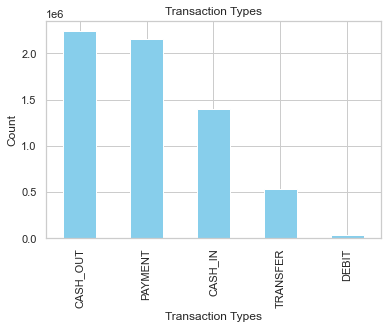

In [ ]:
#Counting the types each that is used for doing transaction
df['type'].value_counts().plot(kind='bar',title='Transaction Types',color='skyblue')
plt.xlabel('Transaction Types')
plt.ylabel('Count')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

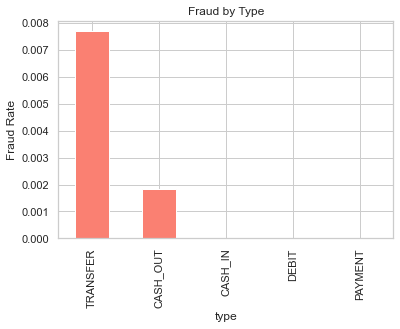

In [31]:
#Checking by which type the highest percentage of fraud took place
fraudy_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraudy_by_type.plot(kind='bar',title='Fraud by Type',color = 'salmon')
plt.ylabel('Fraud Rate')
plt.show

In [33]:
df['amount'].describe().astype(int) #converted into int, as values was in scientific. Also, I can see that min value is 0 so I don't need to do much more data cleaning here. Which I used to to it before.

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int32

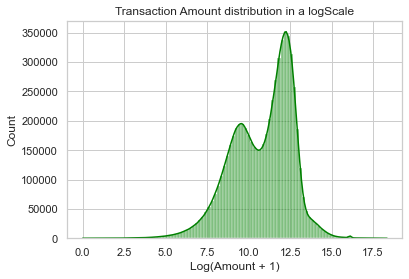

In [35]:
sns.histplot(np.log1p(df['amount']),bins=100,kde=True,color='green')
plt.title('Transaction Amount distribution in a logScale')
plt.xlabel('Log(Amount + 1)')
plt.show()

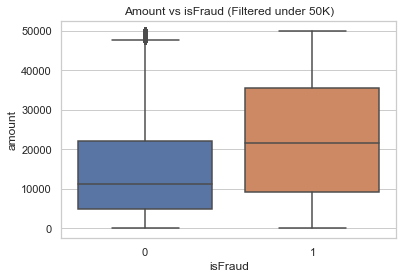

In [ ]:
sns.boxplot(data=df[df['amount']<50000],x="isFraud",y='amount')
plt.title('Amount vs isFraud (Filtered under 50K)')
plt.show()

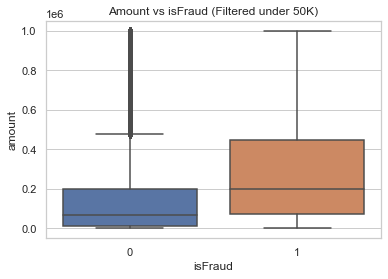

In [44]:
sns.boxplot(data=df[df['amount']<1000000],x="isFraud",y='amount')
plt.title('Amount vs isFraud (Filtered under 50K)')
plt.show()

In [45]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [46]:
#now I need to check as if fraud is detected it means the balance difference in origin as well in destination should be in negative
df['BalanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['BalanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest'] 

In [48]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,BalanceDiffOrig,BalanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [ ]:
(df['BalanceDiffOrig']<0).value_counts() #<0 actually returns a boolean, so you can use sum as well to count the data. But I prefer to use value_counts() as a defualt whenever I need to count the data. 

False    4963367
True     1399253
Name: BalanceDiffOrig, dtype: int64

In [49]:
(df['BalanceDiffDest']<0).value_counts()

False    5123756
True     1238864
Name: BalanceDiffDest, dtype: int64

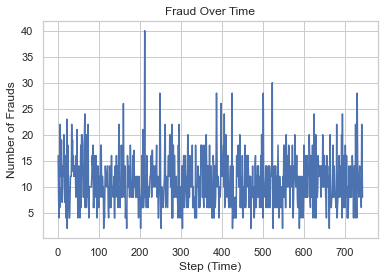

In [59]:
fraud_per_step = df[df['isFraud']==1]['step'].value_counts().sort_index()
plt.plot(fraud_per_step.index,fraud_per_step.values,label='Fraud per step')
plt.xlabel('Step (Time)')
plt.ylabel('Number of Frauds')
plt.title('Fraud Over Time')
plt.show()

In [62]:
df.drop(columns='step',inplace=True)

In [63]:
df.head(2)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,BalanceDiffOrig,BalanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


In [67]:
#now checking which are the top senders, such that I can identify does the fraud took place with the one who do more number of transaction or who do big amount of transaction
top_senders = df['nameOrig'].value_counts()
top_senders

C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
              ..
C98968405      1
C720209255     1
C1567523029    1
C644777639     1
C1280323807    1
Name: nameOrig, Length: 6353307, dtype: int64